# 任务3_1_2 GAN生成模型
本次任务的目标是使用生成对抗网络（GAN）来生成新的数据样本。GAN由两个主要组件组成：生成器（Generator）和判别器（Discriminator）。生成器负责生成新的数据样本，而判别器则负责区分真实数据和生成的数据。

## 1.导入必要的库

In [8]:
import os
# 解决可能出现的 Matplotlib 绘图时 Kernel 崩溃问题
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 检查 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

# 超参数设置
batch_size = 128
epochs = 100  # GAN 通常需要比 VAE 多训练几轮才能出效果
lr_D = 0.0002 # GAN 常用的经典学习率 
lr_G = 0.0002  # GAN 常用的经典学习率
noise_dim = 100 # 随机噪声的维度

当前使用的设备: cpu


## 2.加载数据集

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 将像素值归一化到 [-1, 1]
])

# 加载 MNIST 数据集
# 1. root='./data' 指向你当前目录下的 data 文件夹
# 2. download=False 表示明确不从网络下载，直接使用本地已有数据
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=False)

# 加载 DataLoader
dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

print(f"成功加载本地数据集，共 {len(train_dataset)} 张图片。")

成功加载本地数据集，共 60000 张图片。


## 3.构建生成器和判别器模型
这里采用了一个简单的全连接神经网络作为生成器和判别器的基础架构。生成器接受随机噪声作为输入，并输出生成的数据样本；判别器接受数据样本作为输入，并输出一个概率值，表示该样本是真实的还是生成的。

In [10]:
# # 生成器：从噪声生成图像
# class Generator(nn.Module):
#     def __init__(self, noise_dim, img_dim=784):
#         super(Generator, self).__init__()
#         self.gen = nn.Sequential(
#             nn.Linear(noise_dim, 256),
#             nn.LeakyReLU(0.2),
#             nn.Linear(256, 512),
#             nn.LeakyReLU(0.2),
#             nn.Linear(512, 1024),
#             nn.LeakyReLU(0.2),
#             nn.Linear(1024, img_dim),
#             nn.Sigmoid() # 将输出压缩到 [0, 1] 区间，匹配图像像素
#         )


# 生成器：从噪声生成图像
class Generator(nn.Module):
    def __init__(self, noise_dim, img_dim=784):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),  # -------- 新增 BN 层
            nn.LeakyReLU(0.2),
            
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),  # -------- 新增 BN 层
            nn.LeakyReLU(0.2),
            
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), # -------- 新增 BN 层
            nn.LeakyReLU(0.2),
            
            nn.Linear(1024, img_dim),
            nn.Tanh()  # 将输出压缩到 [-1, 1] 区间，匹配归一化后的图像像素
        )
        
    def forward(self, x):
       return self.gen(x)

# 判别器：区分真实图像和虚假图像
# class Discriminator(nn.Module):
#     def __init__(self, img_dim=784):
#         super(Discriminator, self).__init__()
#         self.disc = nn.Sequential(
#             nn.Linear(img_dim, 1024),
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(1024, 512),
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(256, 1),
#             nn.Sigmoid() # 输出 0~1 的概率，代表是真图的概率
#         )

# # 判别器：物理削减神经元数量，让它变“笨”
# class Discriminator(nn.Module):
#     def __init__(self, img_dim=784):
#         super(Discriminator, self).__init__()
#         self.disc = nn.Sequential(
#             nn.Linear(img_dim, 256), # 第一层直接降到 256 (原来是 1024)
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(256, 128),     # 第二层降到 128 (原来是 512)
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(128, 1),       # 直接输出
#             nn.Sigmoid()
#         )

#判别器：区分真实图像和虚假图像
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid() # 输出 0~1 的概率，代表是真图的概率
        )

    def forward(self, x):
        return self.disc(x)

# 实例化并移动到设备
G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

## 4.定义损失函数和优化器
在GAN中，生成器和判别器的损失函数是相互对立的。生成器的目标是最大化判别器的错误率，而判别器的目标是最小化其错误率。我们使用二元交叉熵作为损失函数，并分别为生成器和判别器定义优化器。

In [11]:
# 课件 P38: 损失函数使用二值交叉熵 (BCE)
criterion = nn.BCELoss()

# 课件 P38: 分别为 D 和 G 建立 optimizer
optimizer_D = optim.Adam(D.parameters(), lr=lr_D)
optimizer_G = optim.Adam(G.parameters(), lr=lr_G)

# 记录 Loss 用于可视化
d_losses = []
g_losses = []

## 5.训练 GAN 模型

开始训练 GAN...
Epoch [1/100] | D Loss: 0.0756 | G Loss: 8.8412
Epoch [5/100] | D Loss: 0.1076 | G Loss: 6.3552
Epoch [10/100] | D Loss: 0.4075 | G Loss: 2.6853
Epoch [15/100] | D Loss: 0.7017 | G Loss: 1.7211
Epoch [20/100] | D Loss: 0.8363 | G Loss: 2.2145
Epoch [25/100] | D Loss: 0.8615 | G Loss: 2.0862
Epoch [30/100] | D Loss: 1.1099 | G Loss: 1.0171
Epoch [35/100] | D Loss: 1.0753 | G Loss: 1.2050
Epoch [40/100] | D Loss: 1.0734 | G Loss: 1.2061
Epoch [45/100] | D Loss: 1.0733 | G Loss: 1.0103
Epoch [50/100] | D Loss: 1.0707 | G Loss: 1.4004
Epoch [55/100] | D Loss: 1.1445 | G Loss: 0.9777
Epoch [60/100] | D Loss: 1.2391 | G Loss: 0.8440
Epoch [65/100] | D Loss: 1.1922 | G Loss: 1.0576
Epoch [70/100] | D Loss: 1.1719 | G Loss: 0.9375
Epoch [75/100] | D Loss: 1.1946 | G Loss: 0.9668
Epoch [80/100] | D Loss: 1.1615 | G Loss: 1.0206
Epoch [85/100] | D Loss: 1.2152 | G Loss: 1.0428
Epoch [90/100] | D Loss: 1.1922 | G Loss: 0.9639
Epoch [95/100] | D Loss: 1.3649 | G Loss: 1.1023
Epoch [100

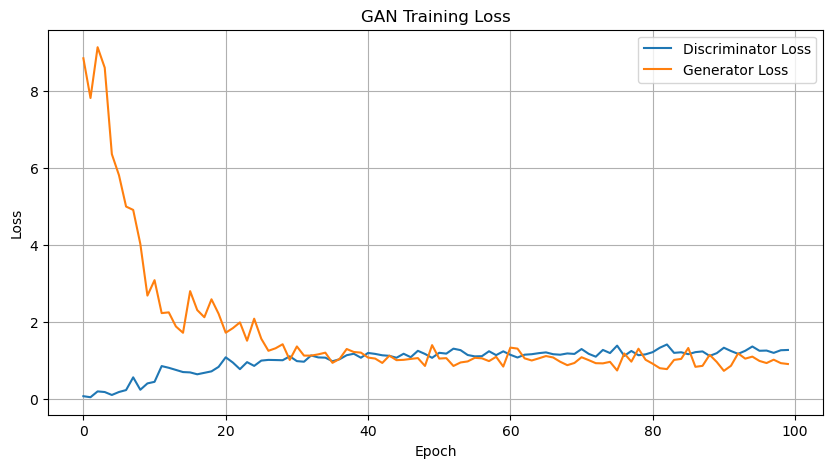

In [12]:
print("开始训练 GAN...")
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        batch_size_cur = imgs.size(0)
        
        # 将图像展平为向量，并移动到 GPU/CPU
        real_imgs = imgs.view(batch_size_cur, -1).to(device)
        
        # 创建真实标签 (1) 和虚假标签 (0)
        real_labels = (torch.ones(batch_size_cur, 1)).to(device)  # 使用 0.9 而不是 1
        fake_labels = (torch.zeros(batch_size_cur, 1)).to(device)
        
        # ==========================================
        # 1. 训练判别器 (Discriminator)
        # ==========================================
        optimizer_D.zero_grad()
        
        # 1.1 真实样本的损失
        outputs_real = D(real_imgs)
        d_loss_real = criterion(outputs_real, real_labels)
        d_loss_real.backward()
        
        # 1.2 虚假样本的损失
        noise = torch.randn(batch_size_cur, noise_dim).to(device)
        fake_imgs = G(noise)
        # 使用 .detach() 是为了避免在更新 D 时计算 G 的梯度
        outputs_fake = D(fake_imgs.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)
        d_loss_fake.backward()
        
        d_loss = d_loss_real + d_loss_fake
        optimizer_D.step()
        
        # ==========================================
        # 2. 训练生成器 (Generator)
        # ==========================================
        optimizer_G.zero_grad()
        
        # 生成器希望判别器将自己生成的虚假样本判定为真实 (标签给 1)
        outputs = D(fake_imgs)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        
        optimizer_G.step()
        
    # 记录每个 epoch 最后的 loss
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# 绘制 Loss 曲线
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

## 6.生成新图像并可视化

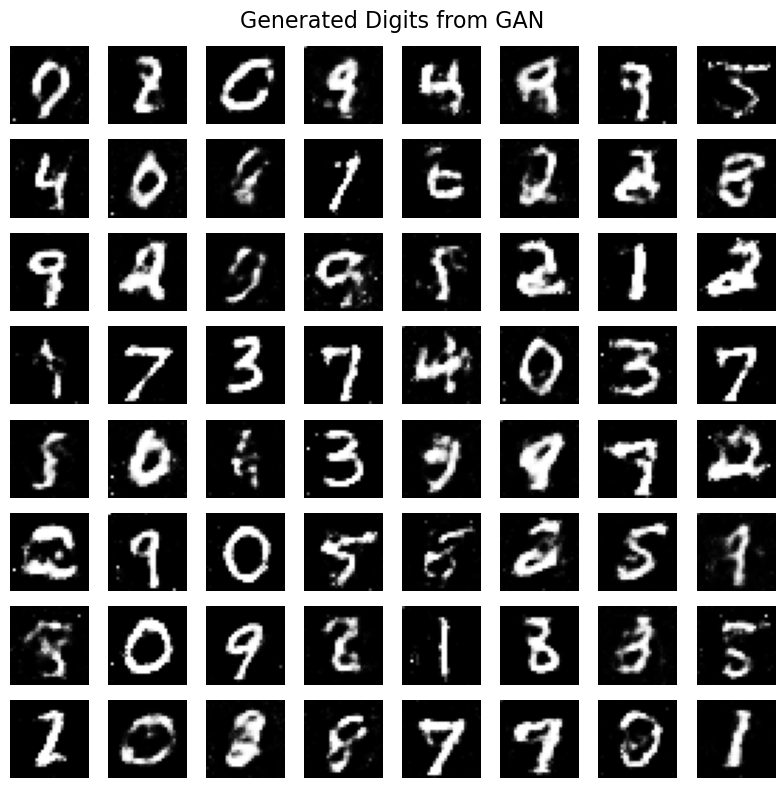

In [13]:
G.eval()
with torch.no_grad():
    # 随机生成 64 个噪声向量
    z = torch.randn(64, noise_dim).to(device)
    
    # 用生成器伪造图像
    generated_imgs = G(z).cpu()

    # <--- 新增这一行：将 [-1, 1] 映射回 [0, 1] 供 matplotlib 正常显示
    generated_imgs = (generated_imgs + 1.0) / 2.0  
    
    # 恢复为图像形状 (64, 1, 28, 28)
    generated_imgs = generated_imgs.view(-1, 1, 28, 28)
    
    # 绘图展示
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated_imgs[i][0], cmap='gray')
        ax.axis('off')
        
    plt.suptitle("Generated Digits from GAN", fontsize=16)
    plt.tight_layout()
    plt.show()